In [1]:
import algorithm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
file_name = "matrix.csv"
file_path = os.path.join("input", file_name)

df = pd.read_csv(file_path, header=None)
A = df.to_numpy()

In [3]:
Q, R = algorithm.qr_decomposition(A)

In [4]:
print("Q =\n", Q)
print("R =\n", R)

Q =
 [[-0.01366988  0.04936708  0.02268104 ... -0.01922383 -0.04544992
   0.0515299 ]
 [-0.03430817  0.00493548  0.04005942 ...  0.05290911  0.00445042
  -0.01943235]
 [-0.02596677 -0.02735985  0.04556317 ...  0.00771137  0.05849388
   0.02755122]
 ...
 [-0.04519395 -0.0440816   0.02273659 ...  0.01018856 -0.03974976
  -0.01885451]
 [ 0.02835314  0.05036318 -0.0564926  ...  0.02544434 -0.01408036
   0.03332807]
 [-0.04202847 -0.03671533  0.03686571 ...  0.0219006   0.05072472
   0.00255929]]
R =
 [[1835.42269325   19.1779423   -37.17495242 ...   30.20734924
    40.05123118    7.63719853]
 [   0.         1831.22362527   94.09356685 ... -106.79482844
    47.17762899  -17.58035857]
 [   0.            0.         1818.55372035 ...  -67.13647484
    40.39219216 -110.14108196]
 ...
 [   0.            0.            0.         ...  126.17685844
    -2.54357003   40.52949073]
 [   0.            0.            0.         ...    0.
    61.45713495  -80.36340597]
 [   0.            0.            0. 

In [5]:
def plot(matrix, title, precision=1e-10):
    matrix_cleaned = matrix.copy()
    matrix_cleaned[abs(matrix_cleaned) < precision] = 0
    nz = np.count_nonzero(matrix_cleaned)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    ax.spy(matrix_cleaned, marker='.', markersize=2, color='b') 
    
    ax.set_title(f"Sparsity Pattern of Matrix {title}")
    ax.set_xlabel(f'nz = {nz}')
    
    ax.set_aspect('equal')
    
    size = matrix.shape[0]
    step = 50 if size <= 500 else 100
    ticks = np.arange(0, size + 1, step)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    
    plt.tight_layout()
    plt.show()

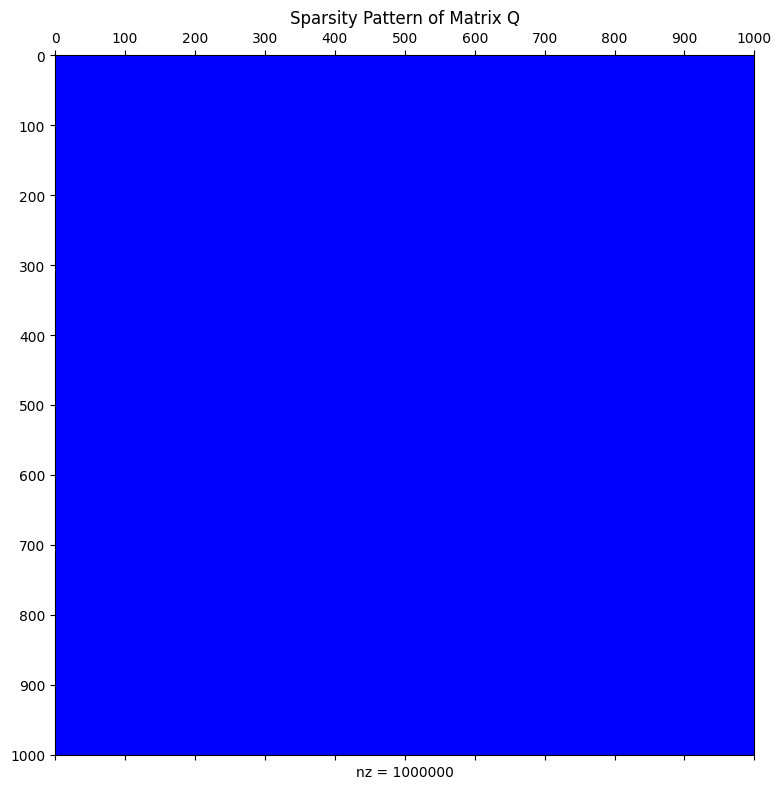

In [6]:
plot(Q, title='Q')

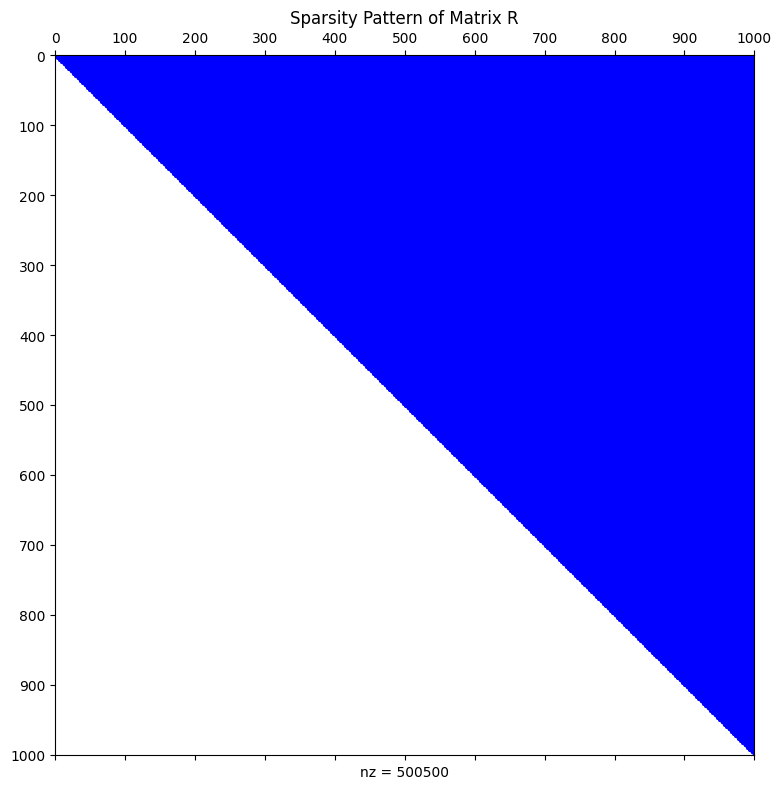

In [7]:
plot(R, title='R')

Computed 1000 eigenvalues
First 20 eigenvalues:
[  362.2693417    389.70071218  -750.43456119  -538.56362524
  -429.17809379  1517.42467497  1618.42431151  1068.75396436
  1119.96306051  1591.2411301   1039.66099173 -1757.30394912
 -1760.65059947 -1432.18838887 -1574.70915512   145.88574545
    90.10571535 -1103.87547116  -922.62610767  -455.99549365]


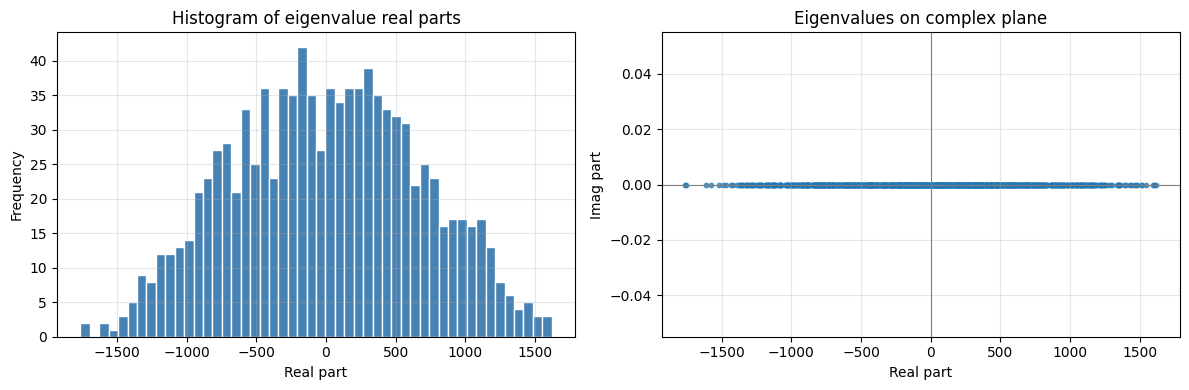

In [8]:
# Fast eigenvalue computation for matrix.csv
# Pure-Python QR iteration is too slow for a huge matrix, so use NumPy's optimized solver.
eigenvalues, n = algorithm.solve_eigenvalues(A)

print(f"Computed {len(eigenvalues)} eigenvalues")
print("First 20 eigenvalues:")
print(eigenvalues[:20])

real_part = np.real(eigenvalues)
imag_part = np.imag(eigenvalues)

plt.figure(figsize=(12, 4))

# Plot 1: distribution of real parts
plt.subplot(1, 2, 1)
plt.hist(real_part, bins=50, color='steelblue', edgecolor='white')
plt.title('Histogram of eigenvalue real parts')
plt.xlabel('Real part')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Plot 2: eigenvalues on complex plane
plt.subplot(1, 2, 2)
plt.scatter(real_part, imag_part, s=10, alpha=0.7)
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('Eigenvalues on complex plane')
plt.xlabel('Real part')
plt.ylabel('Imag part')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

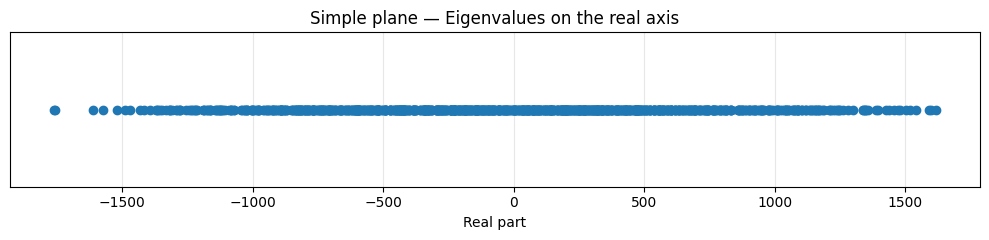

In [9]:
real_vals = np.real(eigenvalues)
zeros = np.zeros_like(real_vals)

plt.figure(figsize=(10, 2.5))
markerline, stemlines, baseline = plt.stem(real_vals, zeros, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.setp(markerline, markersize=6)
plt.gca().axes.get_yaxis().set_visible(False)
plt.title('Simple plane — Eigenvalues on the real axis')
plt.xlabel('Real part')
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()